In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from multipred.plotting import pointplot_morey

In [2]:
# simulate data
np.random.seed(0)
n = 10000
CW_prob = 0.7 # mean probability of CW when the presented orientation is CW
CCW_prob = 0.3 # mean probability of CW when the presented orientation is CCW
exp_diff = .15 # deviation from mean probability caused by predictions
spread = .3 # spread of the data

df = {"mechanism": [], "expected_ori": [], "presented_ori": [], "prob_cw": []}
# neutral trials
for mechanism in ["neutral", "sharpening", "bias"]:
    for expected_ori in ["CW", "CCW"]:
        for presented_ori in ["CW", "CCW"]:
            if mechanism == "neutral":
                prob_cw = CW_prob # + exp_diff
                prob_ccw = CCW_prob # - exp_diff

            elif mechanism == "sharpening":
                if expected_ori == "CW":
                    prob_cw = CW_prob + exp_diff # under this account the probability of CW should increase
                    prob_ccw = CCW_prob # under this account the probability of CW when CCW is unexpected should remain the same
                else:
                    prob_cw = CW_prob
                    prob_ccw = CCW_prob - exp_diff # only the probability of CW should decrease when expected CCW

            elif mechanism == "bias":
                if expected_ori == "CW":
                    prob_cw = CW_prob + exp_diff
                    prob_ccw = CCW_prob + exp_diff # under this account the probability of CW should always increase
                else:
                    prob_cw = CW_prob - exp_diff
                    prob_ccw = CCW_prob - exp_diff # under this account the probability of CW should always decrease

            # Generate the data
            if presented_ori == "CW":
                data = np.random.normal(loc=prob_cw, scale=spread, size=n)
            else:
                data = np.random.normal(loc=prob_ccw, scale=spread, size=n)
                
            df["mechanism"].extend([mechanism]*n)
            df["expected_ori"].extend([expected_ori]*n)
            df["presented_ori"].extend([presented_ori]*n)
            df["prob_cw"].extend(data)

df = pd.DataFrame(df)
df["correct"] = np.where(
    ((df["presented_ori"] == "CW") & (df["prob_cw"] > 0.5)) |
    ((df["presented_ori"] == "CCW") & (df["prob_cw"] < 0.5)),
    1,
    0
)
df["expected_ori"] = np.where(df["mechanism"] == "neutral", "neutral", df["expected_ori"])

df["visual_prediction"] = np.where(
    df["mechanism"] == "neutral",
    "neutral",
    np.where(
        df["presented_ori"] == df["expected_ori"],
        "EXP",
        "UEX"
    )
)

/tmp/ipykernel_9489/1729005420.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


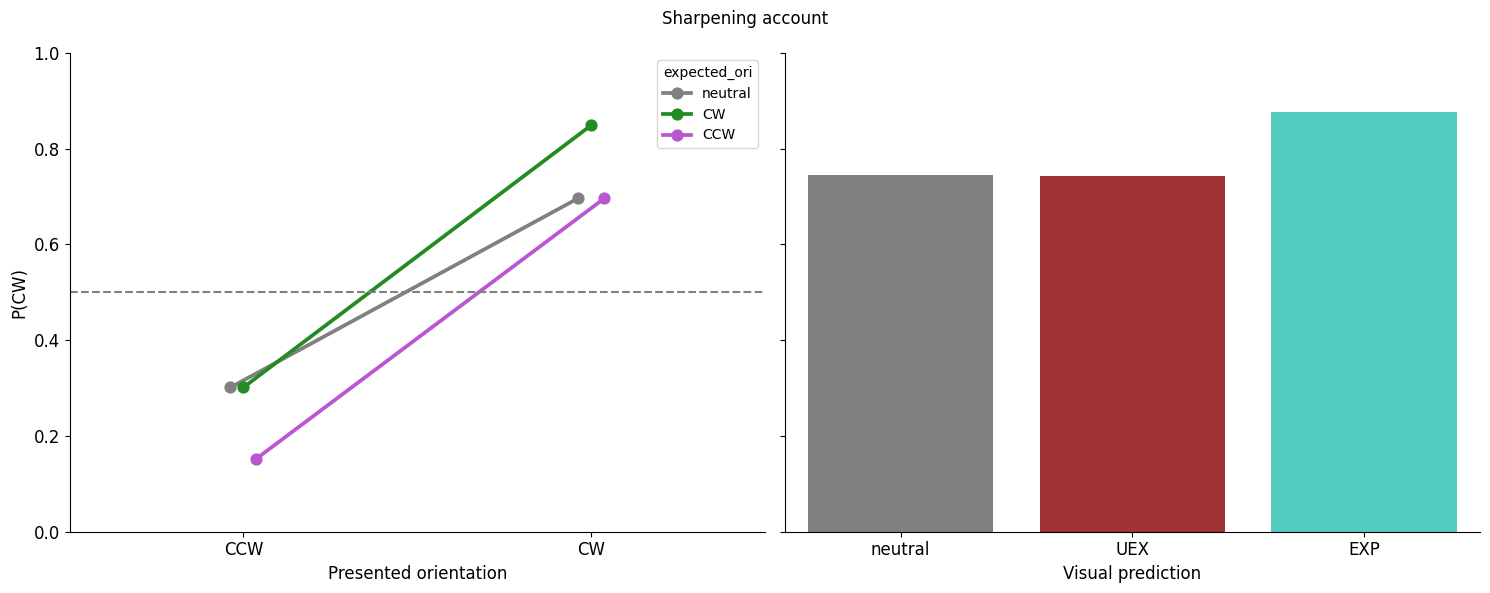

In [9]:
x="presented_ori" # Presented CW or
hue="expected_ori" # expected CW or CCW
y="prob_cw" # probability of choosing CW
savefig = True

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

data=df[df["mechanism"]!= "bias"].copy()
dat = data.groupby([hue, x])[y].mean().reset_index()

palette = ["grey", "forestgreen", "mediumorchid"]
hue_order = ["neutral", "CW", "CCW"]  # explicitly specify the order of hue levels

sns.pointplot(
    data=dat,
    x="presented_ori",
    y="prob_cw",
    hue="expected_ori",
    hue_order=hue_order,     # this ensures consistent mapping
    dodge=True,
    join=True,
    errorbar=None,
    palette=palette,
    ax=ax[0]
)

ax[0].axhline(0.5, color="grey", linestyle="--")
ax[0].set_ylim(0, 1)
ax[0].set_ylabel("P(CW)")
ax[0].set_xlabel("Presented orientation")

x="visual_prediction" # Presented CW or
hue="visual_prediction" # expected CW or CCW
y="correct" # probability of choosing CW

data = df[df["mechanism"]!= "bias"].copy()
dat = data.groupby([x])[y].mean().reset_index()

palette = ["grey", "firebrick", "turquoise"]
cat_type = pd.CategoricalDtype(categories=["neutral", "UEX", "EXP"], ordered=True)
dat["visual_prediction"] = dat["visual_prediction"].astype(cat_type)

sns.barplot(
    data=dat,
    x="visual_prediction",
    y="correct",
    hue="visual_prediction",  # optional, now redundant due to categorical type
    dodge=False,
    palette=palette,
    ax=ax[1]
)

ax[1].set_ylabel("Decoding accuracy")
ax[1].set_xlabel("Visual prediction")

sns.despine()

# increase font size
for a in ax:
    for item in ([a.title, a.xaxis.label, a.yaxis.label] +
                 a.get_xticklabels() + a.get_yticklabels()):
        item.set_fontsize(12)
        
plt.suptitle("Sharpening account")
plt.ylabel("P(CW)")
plt.tight_layout()
if savefig:
    plt.savefig("figures/MVPA/sharpening_simulation.svg", dpi = 300)
plt.show()

/tmp/ipykernel_9489/2659307482.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


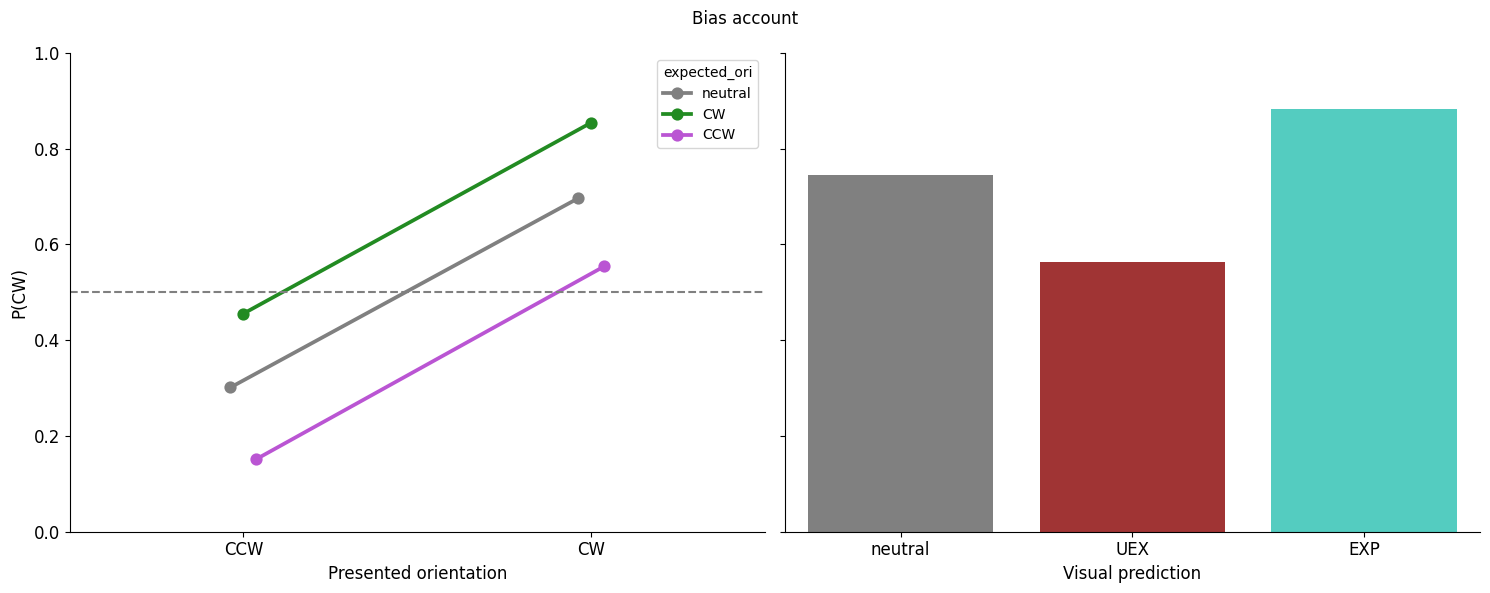

In [10]:
x="presented_ori" # Presented CW or
hue="expected_ori" # expected CW or CCW
y="prob_cw" # probability of choosing CW
savefig = True

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

data=df[df["mechanism"]!= "sharpening"].copy()
dat = data.groupby([hue, x])[y].mean().reset_index()

palette = ["grey", "forestgreen", "mediumorchid"]
hue_order = ["neutral", "CW", "CCW"]  # explicitly specify the order of hue levels

sns.pointplot(
    data=dat,
    x="presented_ori",
    y="prob_cw",
    hue="expected_ori",
    hue_order=hue_order,     # this ensures consistent mapping
    dodge=True,
    join=True,
    errorbar=None,
    palette=palette,
    ax=ax[0]
)

ax[0].axhline(0.5, color="grey", linestyle="--")
ax[0].set_ylim(0, 1)
ax[0].set_ylabel("P(CW)")
ax[0].set_xlabel("Presented orientation")

x="visual_prediction" # Presented CW or
hue="visual_prediction" # expected CW or CCW
y="correct" # probability of choosing CW

data = df[df["mechanism"]!= "sharpening"].copy()
dat = data.groupby([x])[y].mean().reset_index()

palette = ["grey", "firebrick", "turquoise"]
cat_type = pd.CategoricalDtype(categories=["neutral", "UEX", "EXP"], ordered=True)
dat["visual_prediction"] = dat["visual_prediction"].astype(cat_type)

sns.barplot(
    data=dat,
    x="visual_prediction",
    y="correct",
    hue="visual_prediction",  # optional, now redundant due to categorical type
    dodge=False,
    palette=palette,
    ax=ax[1]
)

ax[1].set_ylabel("Decoding accuracy")
ax[1].set_xlabel("Visual prediction")

sns.despine()

# increase font size
for a in ax:
    for item in ([a.title, a.xaxis.label, a.yaxis.label] +
                 a.get_xticklabels() + a.get_yticklabels()):
        item.set_fontsize(12)

plt.suptitle("Bias account")
plt.tight_layout()
if savefig:
    plt.savefig("figures/MVPA/bias_simulation.svg", dpi = 300)
plt.show()